In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

plt.style.use("seaborn-v0_8-whitegrid")

df = pd.read_csv("../data/raw/stock_market_daily.csv", parse_dates=["date"])
sectors = ["Financials", "Technology", "ConsumerStaples", "Utilities", "Energy"]
data = df[["date", "year", "crisis_gfc"] + sectors].dropna().set_index("date")

before = data.loc["2003-01-01":"2007-10-08"]
during = data.loc["2007-10-09":"2009-03-09"]
after  = data.loc["2009-03-10":"2010-12-31"]

weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
portfolio_returns_before = before[sectors].dot(weights)
portfolio_returns_during = during[sectors].dot(weights)
portfolio_returns_after = after[sectors].dot(weights)

# Chow 
crisis_window = data.loc["2005-01-01":"2010-12-31"]
portfolio_returns_window = crisis_window[sectors].dot(weights)

portfolio_returns_window.head()

date
2005-01-03   -0.014598
2005-01-04   -0.010195
2005-01-05   -0.004538
2005-01-06    0.009021
2005-01-07   -0.001674
dtype: float64

Normal fit: mu=-0.00143, sigma=0.02508
Student-t fit: df=2.27, loc=-0.00064, scale=0.01377


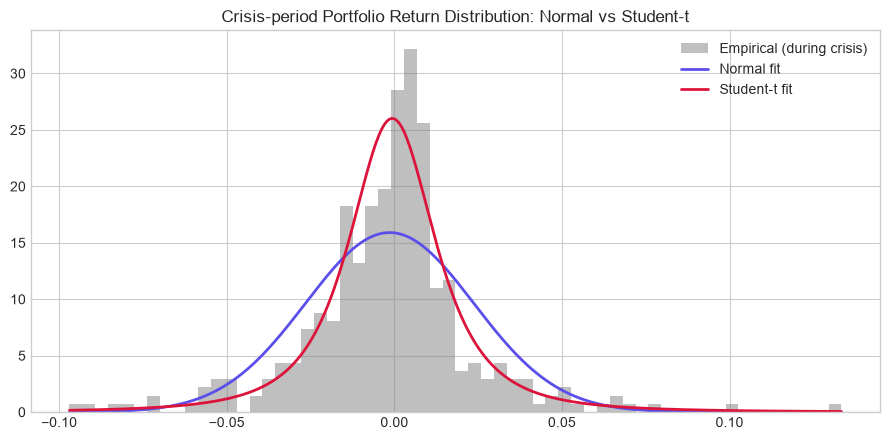

In [2]:
normal_params = stats.norm.fit(portfolio_returns_during)
t_params = stats.t.fit(portfolio_returns_during)

print(f"Normal fit: mu={normal_params[0]:.5f}, sigma={normal_params[1]:.5f}")
print(f"Student-t fit: df={t_params[0]:.2f}, loc={t_params[1]:.5f}, scale={t_params[2]:.5f}")

x = np.linspace(portfolio_returns_during.min(), portfolio_returns_during.max(), 500)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(portfolio_returns_during, bins=60, density=True, alpha=0.5, color="grey", label="Empirical (during crisis)")
ax.plot(x, stats.norm.pdf(x, *normal_params), color="#5B4FE9", lw=2, label="Normal fit")
ax.plot(x, stats.t.pdf(x, *t_params), color="crimson", lw=2, label="Student-t fit")
ax.set_title("Crisis-period Portfolio Return Distribution: Normal vs Student-t")
ax.legend()
plt.tight_layout()
plt.show()

cl = 0.99
var_normal = -stats.norm.ppf(1 - cl, *normal_params)
var_t = -stats.t.ppf(1 - cl, *t_params)

print(f"99% VaR — Normal fit: {var_normal:.2%}")
print(f"99% VaR — Student-t fit: {var_t:.2%}")


# Student-t captures more tail risk than Normal

In [8]:
n_sims = 20_000
horizon_days = 10

mu_vec = during[sectors].mean().values
cov_matrix = during[sectors].cov().values

rng = np.random.default_rng(7)
L = np.linalg.cholesky(cov_matrix)
z = rng.standard_normal((n_sims, horizon_days, len(mu_vec)))
sim_daily_returns = mu_vec + z @ L.T

sim_cum_returns = (1 + sim_daily_returns).prod(axis=1) - 1
sim_portfolio_returns = sim_cum_returns @ weights

mc_var95 = -np.percentile(sim_portfolio_returns, 5)
mc_cvar95 = -sim_portfolio_returns[sim_portfolio_returns <= -mc_var95].mean()

print(f"Monte Carlo 10-day 95% VaR:  {mc_var95}")
print(f"Monte Carlo 10-day 95% CVaR: {mc_cvar95}")

Monte Carlo 10-day 95% VaR:  0.1376703053851334
Monte Carlo 10-day 95% CVaR: 0.16643251552608312


In [11]:
def chow_test(series, break_index):
    y = series.values
    x = np.arange(len(y))
    X = sm.add_constant(x)

    full = sm.OLS(y, X).fit()
    rss_full = np.sum(full.resid ** 2)

    y1, X1 = y[:break_index], X[:break_index]
    y2, X2 = y[break_index:], X[break_index:]
    rss1 = np.sum(sm.OLS(y1, X1).fit().resid ** 2)
    rss2 = np.sum(sm.OLS(y2, X2).fit().resid ** 2)

    k = X.shape[1]
    n = len(y)
    f_stat = ((rss_full - (rss1 + rss2)) / k) / ((rss1 + rss2) / (n - 2 * k))
    p_value = 1 - stats.f.cdf(f_stat, k, n - 2 * k)
    return f_stat, p_value

rolling_vol = portfolio_returns_window.rolling(20).std().dropna()

break_date = pd.Timestamp("2007-10-09")
break_index = rolling_vol.index.get_indexer([break_date], method="nearest")[0]

f_stat, p_value = chow_test(rolling_vol, break_index)
print(f"Chow test at {rolling_vol.index[break_index].date()}: F={f_stat:.2f}, p-value={p_value:.6f}")
print("statistically significant structural break" if p_value < 0.05 
          else "=> no significant break detected")

Chow test at 2007-10-09: F=177.45, p-value=0.000000
statistically significant structural break
